# Ensemble Based Appraoches

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from collections import Counter
from collections import defaultdict
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')
df

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,1,24.434900,8.895360,38.917700,19.541300,2.12927,60,3,448,2.0
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,1,21.035200,14.974000,39.449700,15.410700,2.01000,64,0,434,0.0
2,10.0,1.0,71,56.500000,75.6,26.003679,65,5,94,117,...,2,30.424101,32.959842,56.996400,33.418724,2.17000,54,2,453,0.0
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,2,30.404100,16.779000,58.933800,26.479800,2.45100,45,0,577,1.0
4,18.0,1.0,65,62.206792,77.0,26.000000,68,5,80,116,...,2,28.855800,23.975607,56.996400,33.915114,1.04000,58,1,433,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,7.0,1.0,69,46.070000,49.0,22.250000,58,2,82,103,...,1,21.134424,12.375831,37.154343,16.637908,3.00000,55,0,510,0.0
8456,10.0,1.0,70,56.130000,47.8,28.500000,66,5,80,108,...,1,22.690881,16.569017,48.610678,22.983200,2.00000,57,0,452,1.0
8457,10.0,1.0,70,49.560000,47.2,25.341680,64,7,84,120,...,2,30.581230,32.655921,50.805915,31.594712,2.00000,57,2,528,0.0
8458,15.0,1.0,56,63.790000,99.5,31.100000,67,5,88,108,...,2,30.387635,25.248149,84.622873,46.467581,2.00000,59,1,478,2.0


In [ ]:
X = df.drop(columns=['sii'])
y = df['sii']

num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Variables used:")
print(num_cols)
print("Shape:", X.shape)

Numerical variables used:
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time']
Shape: (8460, 32)


In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

X = pd.DataFrame(
    X,
    columns=num_cols,
    index=df.index
)

X

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,-1.466005,-0.820524,-0.498029,-1.557387,-0.864862,-0.281208,0.008791,0.102306,0.474905,-0.122860,...,-0.642638,-1.376198,-0.146057,-0.145012,-0.237738,-0.190245,-0.180229,0.200805,1.985105,0.088725
1,-0.346958,-0.820524,-0.031912,-1.278690,-0.987775,-1.456603,0.575074,0.102306,-1.100008,0.476259,...,-0.919715,-1.376198,-0.212004,-0.090573,-0.233311,-0.241430,-0.402756,0.617230,-0.969503,-0.073011
2,-0.067196,1.218734,0.123460,-0.094229,-0.229815,-0.280127,-0.368731,0.102306,1.123399,0.101810,...,-0.274774,0.442964,-0.029880,0.070505,-0.087305,-0.018283,-0.104238,-0.423833,1.000236,0.146488
3,-0.346958,-0.820524,0.123460,-0.163903,-0.076175,-0.281208,-0.840633,1.091463,1.401325,0.101810,...,-0.134744,0.442964,-0.030268,-0.074408,-0.071184,-0.104267,0.420034,-1.360791,-0.969503,1.579007
4,2.170899,1.218734,-0.062986,0.701003,-0.193966,-0.281208,-0.085589,0.102306,-0.173589,0.026920,...,-0.274774,0.442964,-0.060302,-0.009956,-0.087305,-0.012132,-2.212521,-0.007408,0.015367,-0.084563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,-0.906481,1.218734,0.061311,-1.547632,-0.910954,-1.383141,-1.029394,-2.865163,0.011695,-0.946650,...,-0.961828,-1.376198,-0.210079,-0.113842,-0.252411,-0.226223,1.444323,-0.319727,-0.969503,0.804985
8456,-0.067196,1.218734,0.092386,-0.145788,-0.941683,0.453414,-0.274350,0.102306,-0.173589,-0.572200,...,-0.725216,-1.376198,-0.179888,-0.076288,-0.157083,-0.147595,-0.421414,-0.111514,-0.969503,0.134936
8457,-0.067196,1.218734,0.092386,-1.061307,-0.957047,-0.474654,-0.463111,2.080619,0.196979,0.326479,...,-1.129565,0.442964,-0.026832,0.067784,-0.138816,-0.040885,-0.421414,-0.111514,1.000236,1.012931
8458,1.331614,1.218734,-0.342657,0.921620,0.382186,1.217421,-0.179970,0.102306,0.567547,-0.572200,...,0.282455,0.442964,-0.030588,0.001441,0.142574,0.143412,-0.421414,0.096698,0.015367,0.435303


## LODA

In [6]:
from pyod.models.loda import LODA

In [7]:
outloda = LODA()
outloda.fit(X)

,contamination,0.1
,n_bins,10
,n_random_cuts,100


In [8]:
outliers = outloda.predict(X)

In [9]:
outloda.decision_scores_

array([0.03247274, 0.03234493, 0.03260987, ..., 0.03185458, 0.03100837,
       0.03266094], shape=(8460,))

In [10]:
print(min(outloda.decision_scores_))
print(max(outloda.decision_scores_))

0.025461163243835263
0.09394787583893809


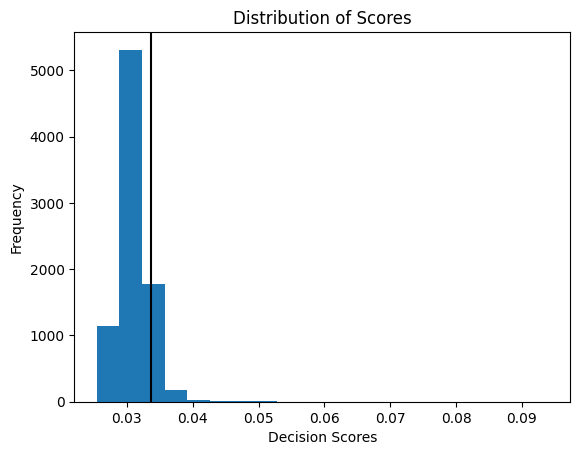

In [11]:
# Plotting the decision scores
# The black vertical line indicates: points to its left are inliers, to its right are outliers.

plt.hist(outloda.decision_scores_, bins=20)
plt.axvline(np.min(outloda.decision_scores_[np.where(outliers==1)]), c='k')
plt.title('Distribution of Scores')
plt.xlabel('Decision Scores')
plt.ylabel('Frequency')
plt.show()

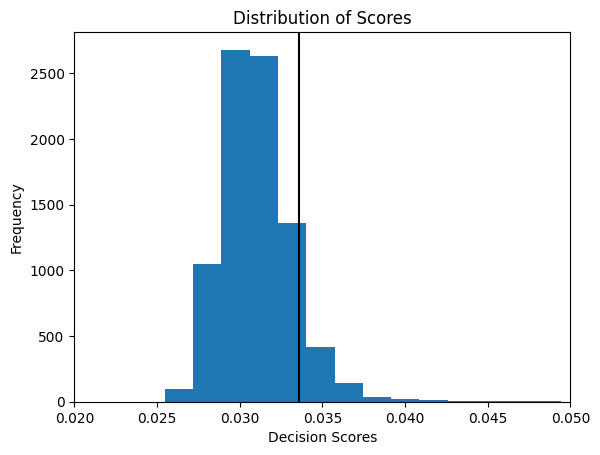

In [12]:
plt.hist(outloda.decision_scores_, bins=40)
plt.axvline(np.min(outloda.decision_scores_[np.where(outliers==1)]), c='k')
plt.title('Distribution of Scores')
plt.xlabel('Decision Scores')
plt.ylabel('Frequency')
plt.xlim(0.02,0.05)
plt.show()

In [13]:
# Outliers count:
# predict returns 0 for an inlier and 1 for an outlier
np.unique(outliers, return_counts=True)

(array([0, 1]), array([7614,  846]))

In [14]:
n_out = outliers[outliers == 1].sum()
perc_out = n_out / len(outliers) * 100

print("Number of LODA outliers:", n_out)
print("Percentage of LODA outliers:", round(perc_out, 3), "%")

Number of LODA outliers: 846
Percentage of LODA outliers: 10.0 %


In [15]:
from standardize_labels import standardize_labels 
# 1. import matrix
od_results = pd.read_csv('./Outliers/outliers_matrix.csv').set_index('row_id')

# 2. Unify labels (LODA uses 1 for outliers, we want 1)
new_standard_labels = standardize_labels(outliers, method_type='pyod_or_manual')

# 3. Add the new column to the existing DataFrame
od_results['outlier_LODA'] = new_standard_labels

# 4. Overwrite the master file with the added column
od_results.to_csv('./Outliers/outliers_matrix.csv', index_label='row_id')

In [16]:
df_outliers = pd.DataFrame({
    'score': outloda.decision_scores_,
    'outlier': outliers
})
df_outliers

,score,outlier
0,0.032473,0
1,0.032345,0
2,0.032610,0
3,0.030409,0
4,0.031641,0
...,...,...
8455,0.034194,1
8456,0.032010,0
8457,0.031855,0
8458,0.031008,0


In [17]:
df_outliers.describe()

,score,outlier
count,8460.000000,8460.000000
mean,0.031068,0.100000
std,0.002391,0.300018
min,0.025461,0.000000
25%,0.029584,0.000000
50%,0.030846,0.000000
75%,0.032225,0.000000
max,0.093948,1.000000


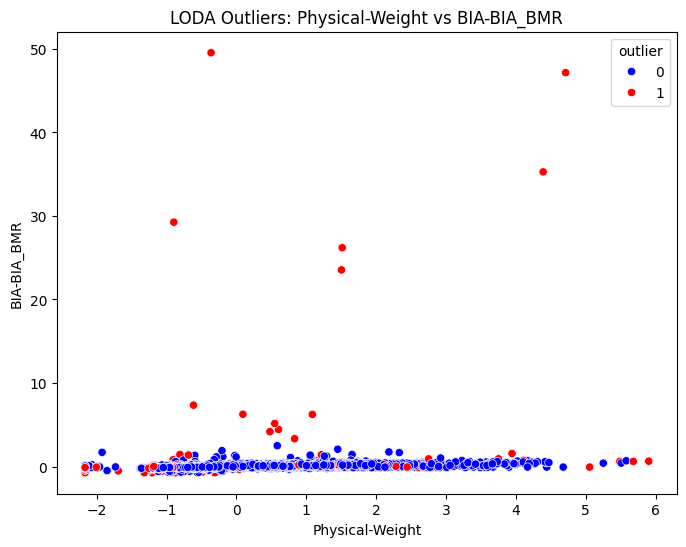

In [18]:
# Visualizing normal vs outlier observations in a scatter plot using two numerical variables
x_col = num_cols[4]
y_col = num_cols[20]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_outliers.join(X),
    x=x_col,
    y=y_col,
    hue="outlier",
    palette={0: "blue", 1: "red"}
)

plt.title(f"LODA Outliers: {x_col} vs {y_col}")
plt.show()

In [19]:
# PCA Visualization of outliers
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df.index)
df_pca

,PC1,PC2
0,-2.584351,0.485096
1,-2.839696,0.304753
2,-0.698818,0.000424
3,-0.332599,-0.038877
4,0.743936,-0.376336
...,...,...
8455,-3.323720,0.538533
8456,-1.817244,0.397558
8457,-0.717765,-0.246349
8458,1.339937,-0.329919


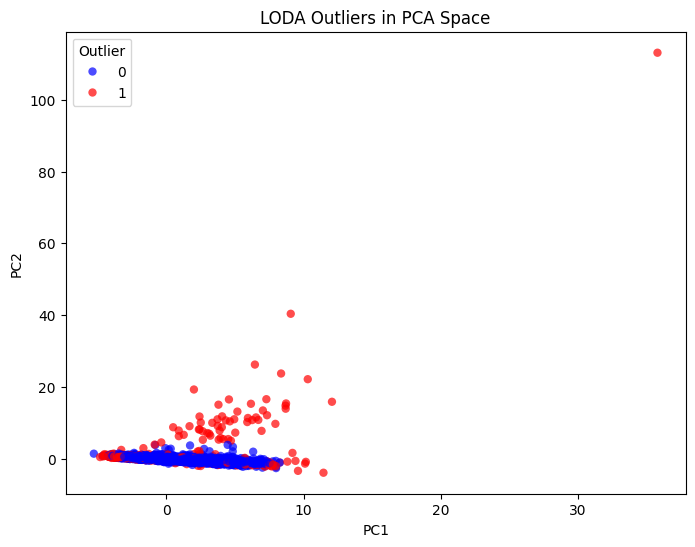

In [20]:
df_pca = df_pca.join(df_outliers)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='outlier',
    palette={0: 'blue', 1: 'red'},
    alpha=0.7,
    edgecolor='none'
)
plt.title('LODA Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Outlier')
plt.show()